In [1]:
using NCDatasets, Plots

# Data Source
Data was sourced from the [Copernicus Global Ocean Physics Reanalysis](https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/download). Data was pulled between the bounds of -77.44 to -70.63 longitude and 31.543 to 37.235 latitude (to cover the region off the coast of NC near Hatteras).

The data was pulled at the surface level (depth 0.49 m as is the lowest depth allowed by the dataset) between the date ranges of 23/10/2025 to 23/12/2025.

In [ ]:
# load dataset
ds = NCDataset("../gulf_stream_oct25_to_dec25.nc")

Dataset: gulf_stream_oct25_to_dec25.nc
Group: /

Dimensions
   time = 62
   depth = 1
   latitude = 68
   longitude = 82

Variables
  time   (62)
    Datatype:    Dates.DateTime (Float64)
    Dimensions:  time
    Attributes:
     standard_name        = time
     long_name            = Time
     units                = seconds since 1970-01-01 00:00:00
     calendar             = gregorian
     axis                 = T

  depth   (1)
    Datatype:    Float32 (Float32)
    Dimensions:  depth
    Attributes:
     standard_name        = depth
     long_name            = Depth
     units                = m
     unit_long            = Meters
     axis                 = Z
     positive             = down

  latitude   (68)
    Datatype:    Float32 (Float32)
    Dimensions:  latitude
    Attributes:
     standard_name        = latitude
     long_name            = Latitude
     units                = degrees_north
     unit_long            = Degrees North
     axis                 = Y

  longit

In [3]:
# Get variables
times = ds["time"][:];
lat = ds["latitude"][:];
lon = ds["longitude"][:];

# Get velocity components
u_vel = ds["uo"][:, :, :, :];
v_vel = ds["vo"][:, :, :, :];

In [4]:
speed_anim = @animate for t in 1:length(times)
    contourf(
        lon,
        lat,
        sqrt.(u_vel[:, :, 1, t].^2 .+ v_vel[:, :, 1, t].^2)',
        title = "Ocean Currents Speed on $(times[t])",
        xlabel = "Longitude",
        ylabel = "Latitude",
        colorbar_title = "Speed (m/s)",
        levels = 20,
        c = :viridis,
    )
    vmin = 0.0
    vmax = 3.0
    plot!(clims=(vmin, vmax))
end

mp4(speed_anim, "ocean_currents_speed.mp4", fps = 10)

┌ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\data_download\ocean_currents_speed.mp4
└ @ Plots C:\Users\kavin\.julia\packages\Plots\xC48f\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\data_download\\ocean_currents_speed.mp4")

# Stream-Aligned Path

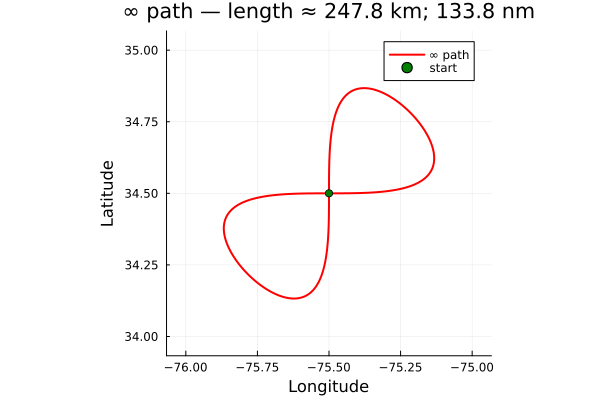

In [16]:
# thinner infinity-shaped path centered at (-75.5, 34.5)
t = range(0, 2π, length=400)
amp_lon = 0.4
amp_lat = 0.2
cx, cy = -75.5, 34.5

lon0 = cx .+ amp_lon .* sin.(t)
lat0 = cy .+ amp_lat .* sin.(2 .* t)

# rotate by 45 degrees around center
θ = π/4
dx = lon0 .- cx
dy = lat0 .- cy
lon_path = cx .+ (dx .* cos(θ) .- dy .* sin(θ))
lat_path = cy .+ (dx .* sin(θ) .+ dy .* cos(θ))

path = collect(zip(lon_path, lat_path))

# haversine distance (meters) and conversions
R = 6_371_000.0
deg2rad(x) = x * π / 180

haversine(lon1, lat1, lon2, lat2) = begin
    dlat = deg2rad(lat2 - lat1)
    dlon = deg2rad(lon2 - lon1)
    a = sin(dlat/2)^2 + cos(deg2rad(lat1)) * cos(deg2rad(lat2)) * sin(dlon/2)^2
    2 * R * atan(sqrt(a), sqrt(1 - a)) # meters
end

# conversion helpers
m2km(m) = m / 1000.0
m2nm(m) = m / 1852.0  # nautical miles

# helper to compute path lengths in m, km, nm
function path_lengths(lons, lats)
    n = length(lons)
    total_m = sum(haversine(lons[i], lats[i], lons[(i % n) + 1], lats[(i % n) + 1]) for i in 1:n)
    (total_m, m2km(total_m), m2nm(total_m))
end

n = length(lon_path)
total_length_m = sum(haversine(lon_path[i], lat_path[i], lon_path[(i % n) + 1], lat_path[(i % n) + 1]) for i in 1:n)

# quick plot with length in title
plot(lon_path, lat_path;
    lw=2, lc=:red, label="∞ path",
    title = "∞ path — length ≈ $(round(m2km(total_length_m); digits=1)) km; $(round(m2nm(total_length_m); digits=1)) nm",
    xlabel="Longitude", ylabel="Latitude",
    xlims=(minimum(lon_path)-0.2, maximum(lon_path)+0.2),
    ylims=(minimum(lat_path)-0.2, maximum(lat_path)+0.2),
    aspect_ratio=:equal)
scatter!([lon_path[1]], [lat_path[1]]; color=:green, label="start")

In [17]:
speed_anim_w_path_full = @animate for t in 1:length(times)
    contourf(
        lon,
        lat,
        sqrt.(u_vel[:, :, 1, t].^2 .+ v_vel[:, :, 1, t].^2)',
        title = "Ocean Currents Speed on $(times[t])",
        xlabel = "Longitude",
        ylabel = "Latitude",
        colorbar_title = "Speed (m/s)",
        levels = 20,
        c = :viridis,
    )
    vmin = 0.0
    vmax = 3.0
    plot!(clims=(vmin, vmax))
    plot!(lon_path, lat_path; lw=2, lc=:red, label="∞ path")
    scatter!([lon_path[1]], [lat_path[1]]; color=:green, label="start")
end

mp4(speed_anim_w_path_full, "ocean_currents_speed_with_path_full_domain.mp4", fps = 10)

┌ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\data_download\ocean_currents_speed_with_path_full_domain.mp4
└ @ Plots C:\Users\kavin\.julia\packages\Plots\xC48f\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\data_download\\ocean_currents_speed_with_path_full_domain.mp4")

In [18]:
# compute zoom bounds around the path (with small padding)
lon_min, lon_max = minimum(lon_path), maximum(lon_path)
lat_min, lat_max = minimum(lat_path), maximum(lat_path)
pad_lon = 0.1 * (lon_max - lon_min) + 0.05
pad_lat = 0.1 * (lat_max - lat_min) + 0.05
xlims = (lon_min - pad_lon, lon_max + pad_lon)
ylims = (lat_min - pad_lat, lat_max + pad_lat)

speed_anim_w_path = @animate for t in 1:length(times)
    contourf(
        lon,
        lat,
        sqrt.(u_vel[:, :, 1, t].^2 .+ v_vel[:, :, 1, t].^2)',
        title = "Ocean Currents Speed on $(times[t])",
        xlabel = "Longitude",
        ylabel = "Latitude",
        colorbar_title = "Speed (m/s)",
        levels = 20,
        c = :viridis,
    )
    vmin = 0.0
    vmax = 3.0
    plot!(clims=(vmin, vmax), xlims=xlims, ylims=ylims)
    plot!(lon_path, lat_path; lw=2, lc=:red, label="∞ path")
    scatter!([lon_path[1]], [lat_path[1]]; color=:green, label="start")
end

mp4(speed_anim_w_path, "ocean_currents_speed_with_path.mp4", fps = 10)

┌ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\data_download\ocean_currents_speed_with_path.mp4
└ @ Plots C:\Users\kavin\.julia\packages\Plots\xC48f\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\data_download\\ocean_currents_speed_with_path.mp4")

# Perpendicular Path

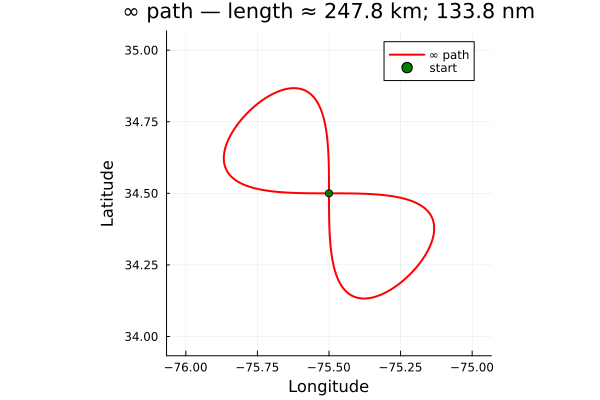

In [19]:
# thinner infinity-shaped path centered at (-75.5, 34.5)
t = range(0, 2π, length=400)
amp_lon = 0.4
amp_lat = 0.2
cx, cy = -75.5, 34.5

lon0 = cx .+ amp_lon .* sin.(t)
lat0 = cy .+ amp_lat .* sin.(2 .* t)

# rotate by -45 degrees around center (convert degrees to radians)
θ = -45 * π / 180
dx = lon0 .- cx
dy = lat0 .- cy
lon_path = cx .+ (dx .* cos(θ) .- dy .* sin(θ))
lat_path = cy .+ (dx .* sin(θ) .+ dy .* cos(θ))

path = collect(zip(lon_path, lat_path))

# haversine distance (meters) and conversions
R = 6_371_000.0
deg2rad(x) = x * π / 180

haversine(lon1, lat1, lon2, lat2) = begin
    dlat = deg2rad(lat2 - lat1)
    dlon = deg2rad(lon2 - lon1)
    a = sin(dlat/2)^2 + cos(deg2rad(lat1)) * cos(deg2rad(lat2)) * sin(dlon/2)^2
    2 * R * atan(sqrt(a), sqrt(1 - a)) # meters
end

# conversion helpers
m2km(m) = m / 1000.0
m2nm(m) = m / 1852.0  # nautical miles

# helper to compute path lengths in m, km, nm
function path_lengths(lons, lats)
    n = length(lons)
    total_m = sum(haversine(lons[i], lats[i], lons[(i % n) + 1], lats[(i % n) + 1]) for i in 1:n)
    (total_m, m2km(total_m), m2nm(total_m))
end

n = length(lon_path)
total_length_m = sum(haversine(lon_path[i], lat_path[i], lon_path[(i % n) + 1], lat_path[(i % n) + 1]) for i in 1:n)

# quick plot with length in title
plot(lon_path, lat_path;
    lw=2, lc=:red, label="∞ path",
    title = "∞ path — length ≈ $(round(m2km(total_length_m); digits=1)) km; $(round(m2nm(total_length_m); digits=1)) nm",
    xlabel="Longitude", ylabel="Latitude",
    xlims=(minimum(lon_path)-0.2, maximum(lon_path)+0.2),
    ylims=(minimum(lat_path)-0.2, maximum(lat_path)+0.2),
    aspect_ratio=:equal)
scatter!([lon_path[1]], [lat_path[1]]; color=:green, label="start")

In [20]:
speed_anim_w_path_full_perp = @animate for t in 1:length(times)
    contourf(
        lon,
        lat,
        sqrt.(u_vel[:, :, 1, t].^2 .+ v_vel[:, :, 1, t].^2)',
        title = "Ocean Currents Speed on $(times[t])",
        xlabel = "Longitude",
        ylabel = "Latitude",
        colorbar_title = "Speed (m/s)",
        levels = 20,
        c = :viridis,
    )
    vmin = 0.0
    vmax = 3.0
    plot!(clims=(vmin, vmax))
    plot!(lon_path, lat_path; lw=2, lc=:red, label="∞ path")
    scatter!([lon_path[1]], [lat_path[1]]; color=:green, label="start")
end

mp4(speed_anim_w_path_full_perp, "ocean_currents_speed_with_path_full_domain_perp.mp4", fps = 10)

┌ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\data_download\ocean_currents_speed_with_path_full_domain_perp.mp4
└ @ Plots C:\Users\kavin\.julia\packages\Plots\xC48f\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\data_download\\ocean_currents_speed_with_path_full_domain_perp.mp4")

In [21]:
# compute zoom bounds around the path (with small padding)
lon_min, lon_max = minimum(lon_path), maximum(lon_path)
lat_min, lat_max = minimum(lat_path), maximum(lat_path)
pad_lon = 0.1 * (lon_max - lon_min) + 0.05
pad_lat = 0.1 * (lat_max - lat_min) + 0.05
xlims = (lon_min - pad_lon, lon_max + pad_lon)
ylims = (lat_min - pad_lat, lat_max + pad_lat)

speed_anim_w_path_perp = @animate for t in 1:length(times)
    contourf(
        lon,
        lat,
        sqrt.(u_vel[:, :, 1, t].^2 .+ v_vel[:, :, 1, t].^2)',
        title = "Ocean Currents Speed on $(times[t])",
        xlabel = "Longitude",
        ylabel = "Latitude",
        colorbar_title = "Speed (m/s)",
        levels = 20,
        c = :viridis,
    )
    vmin = 0.0
    vmax = 3.0
    plot!(clims=(vmin, vmax), xlims=xlims, ylims=ylims)
    plot!(lon_path, lat_path; lw=2, lc=:red, label="∞ path")
    scatter!([lon_path[1]], [lat_path[1]]; color=:green, label="start")
end

mp4(speed_anim_w_path_perp, "ocean_currents_speed_with_path_perp.mp4", fps = 10)

┌ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\data_download\ocean_currents_speed_with_path_perp.mp4
└ @ Plots C:\Users\kavin\.julia\packages\Plots\xC48f\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\data_download\\ocean_currents_speed_with_path_perp.mp4")